Saving full_sweep.csv to full_sweep.csv
Loaded 128 rows
variant
baseline         32
fused            32
softmax_fixed    32
tiled            32
Name: count, dtype: int64

=== Four-Way Speedup over Baseline ===
   B      N    d     Base    Tiled   SoftFix    Fused |   Tiled   SoftFix    Fused
                     (ms)     (ms)      (ms)     (ms) |   spdup     spdup    spdup
-------------------------------------------------------------------------------------
   1    128   64    0.049    0.045     0.016    0.022 |   1.091x    3.000x   2.187x
   4    128   64    0.074    0.056     0.031    0.061 |   1.326x    2.423x   1.210x
  16    128   64    0.160    0.092     0.085    0.215 |   1.739x    1.887x   0.744x
  32    128   64    0.273    0.142     0.160    0.422 |   1.920x    1.707x   0.647x
   1    256   64    0.168    0.149     0.033    0.061 |   1.124x    5.119x   2.730x
   4    256   64    0.261    0.196     0.090    0.211 |   1.331x    2.895x   1.237x
  16    256   64    0.599    0.340

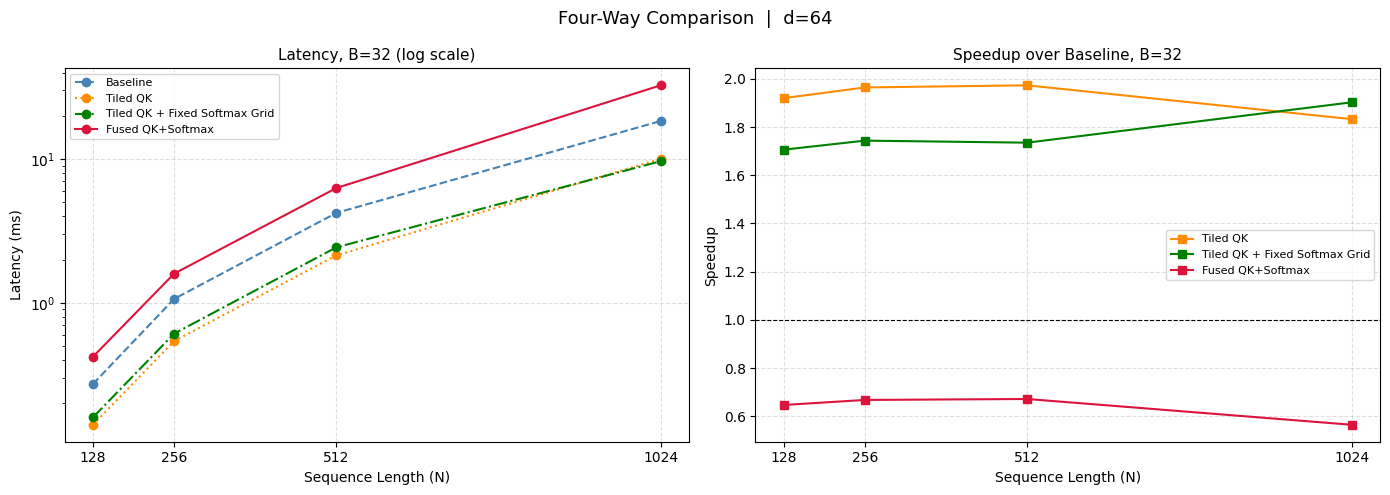

Saved: week4_comparison_d64.png


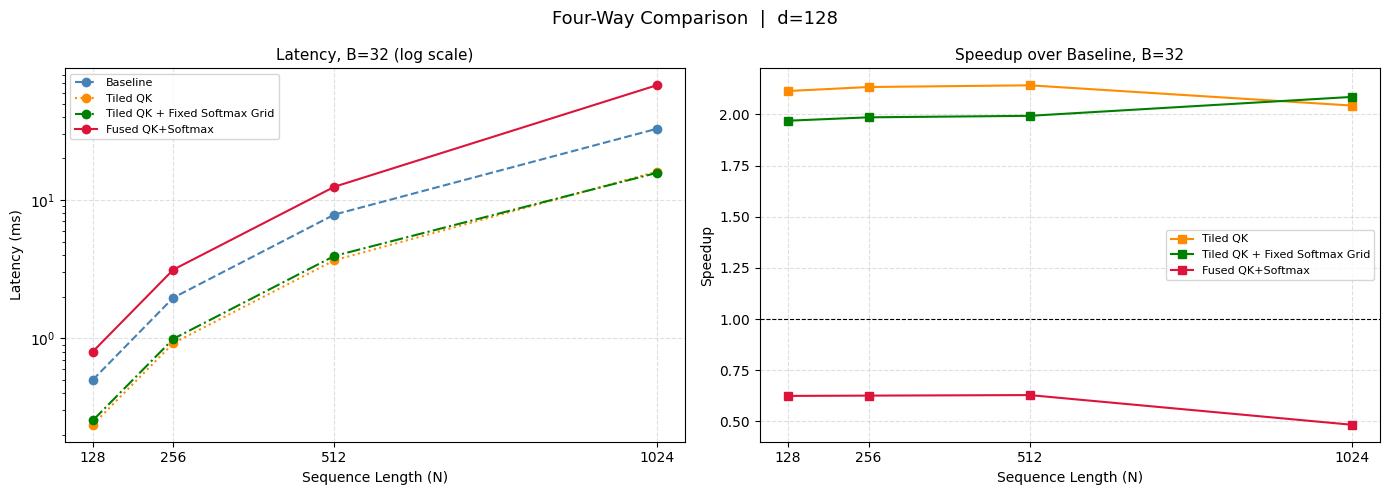

Saved: week4_comparison_d128.png


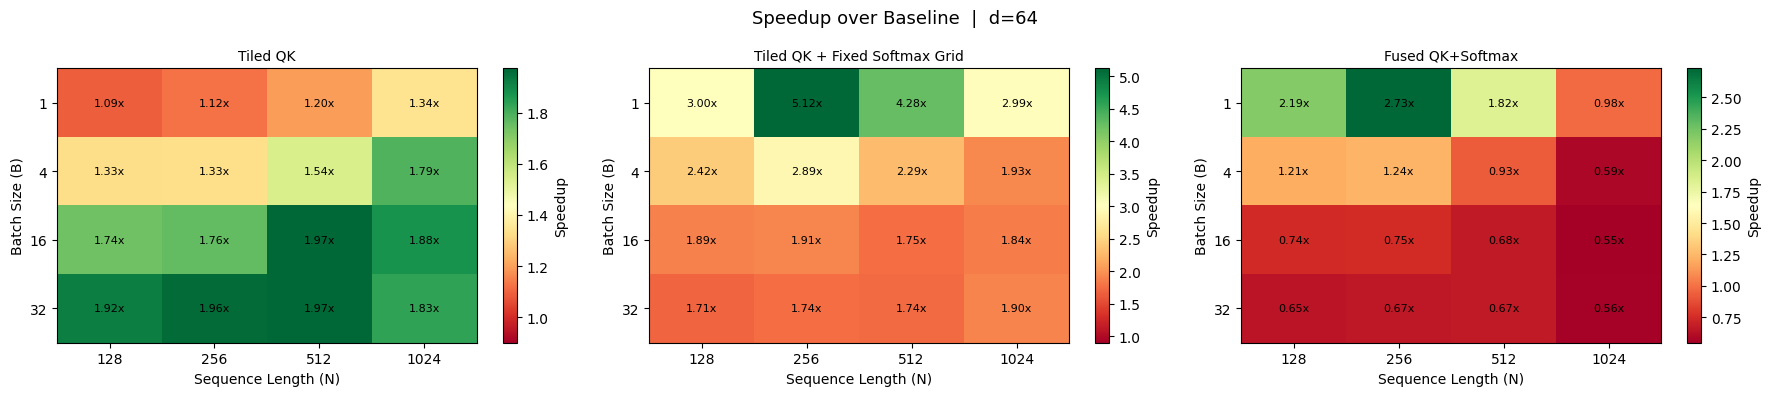

Saved: week4_speedup_heatmap_d64.png


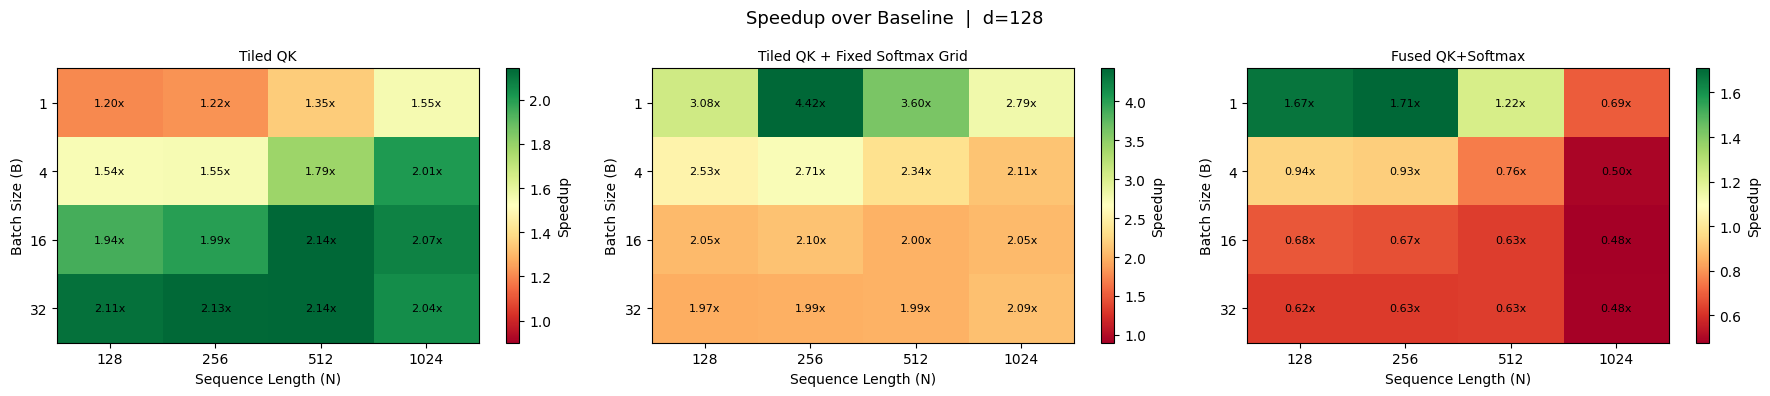

Saved: week4_speedup_heatmap_d128.png

=== Spotlight: B=32, N=1024 (high DRAM pressure) ===
  baseline             d=64  18.393 ms  (1.00x over baseline)
  tiled                d=64  10.033 ms  (1.83x over baseline)
  softmax_fixed        d=64  9.665 ms  (1.90x over baseline)
  fused                d=64  32.586 ms  (0.56x over baseline)
  baseline             d=128  32.776 ms  (1.00x over baseline)
  tiled                d=128  16.044 ms  (2.04x over baseline)
  softmax_fixed        d=128  15.720 ms  (2.09x over baseline)
  fused                d=128  67.718 ms  (0.48x over baseline)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All week4 plots downloaded.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Week 4 — Four-Way Variant Comparison Analysis (Colab)          ║
# ║                                                                  ║
# ║  Variants: baseline | tiled | softmax_fixed | fused             ║
# ║  Addresses professor feedback:                                   ║
# ║    1. Grid fix isolated from full fusion                         ║
# ║    2. Analysis at representative configs incl. B=32, N=1024     ║
# ╚══════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────
# Cell 1 — Upload and load
# ─────────────────────────────────────────────────────────────────

from google.colab import files
import pandas as pd
import numpy as np
import io

uploaded = files.upload()
fname = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[fname]))

VARIANTS  = ["baseline", "tiled", "softmax_fixed", "fused"]
COLORS    = {"baseline": "steelblue", "tiled": "darkorange",
             "softmax_fixed": "green",  "fused": "crimson"}
LABELS    = {"baseline": "Baseline", "tiled": "Tiled QK",
             "softmax_fixed": "Tiled QK + Fixed Softmax Grid",
             "fused": "Fused QK+Softmax"}

print(f"Loaded {len(df)} rows")
print(df.groupby("variant").size().rename("count"))


# ─────────────────────────────────────────────────────────────────
# Cell 2 — Four-way speedup table
# Addresses feedback: isolate grid fix vs full fusion
# ─────────────────────────────────────────────────────────────────

base = df[df["variant"] == "baseline"][["B","N","d","latency_ms"]].rename(
    columns={"latency_ms": "lat_base"})

rows = []
for v in ["tiled", "softmax_fixed", "fused"]:
    sub = df[df["variant"] == v][["B","N","d","latency_ms"]].rename(
        columns={"latency_ms": f"lat_{v}"})
    base = base.merge(sub, on=["B","N","d"])

for v in ["tiled", "softmax_fixed", "fused"]:
    base[f"speedup_{v}"] = base["lat_base"] / base[f"lat_{v}"]

print("\n=== Four-Way Speedup over Baseline ===")
print(f"{'B':>4} {'N':>6} {'d':>4} {'Base':>8} {'Tiled':>8} "
      f"{'SoftFix':>9} {'Fused':>8} | "
      f"{'Tiled':>7} {'SoftFix':>9} {'Fused':>8}")
print(f"{'':>4} {'':>6} {'':>4} {'(ms)':>8} {'(ms)':>8} "
      f"{'(ms)':>9} {'(ms)':>8} | "
      f"{'spdup':>7} {'spdup':>9} {'spdup':>8}")
print("-" * 85)
for _, r in base.sort_values(["d","N","B"]).iterrows():
    print(f"{int(r.B):>4} {int(r.N):>6} {int(r.d):>4} "
          f"{r.lat_base:>8.3f} {r.lat_tiled:>8.3f} "
          f"{r.lat_softmax_fixed:>9.3f} {r.lat_fused:>8.3f} | "
          f"{r.speedup_tiled:>7.3f}x {r.speedup_softmax_fixed:>8.3f}x "
          f"{r.speedup_fused:>7.3f}x")

print(f"\n--- Mean speedups ---")
for v in ["tiled", "softmax_fixed", "fused"]:
    print(f"  {LABELS[v]:40s}: {base[f'speedup_{v}'].mean():.3f}x")


# ─────────────────────────────────────────────────────────────────
# Cell 3 — Isolating the contribution: grid fix vs fusion
# Key result addressing professor's first comment
# ─────────────────────────────────────────────────────────────────

print("\n=== Decomposing Softmax Bottleneck ===")
print("For each config, how much of the 'fused' gain comes from")
print("the grid fix alone vs the additional DRAM elimination?\n")

base["grid_fix_pct"] = (
    (base["lat_tiled"] - base["lat_softmax_fixed"]) /
    (base["lat_tiled"] - base["lat_fused"]) * 100
).clip(0, 100)

base["fusion_extra_pct"] = 100 - base["grid_fix_pct"]

print(f"{'B':>4} {'N':>6} {'d':>4} | "
      f"{'Tiled→SoftFix':>14} {'SoftFix→Fused':>14} | "
      f"{'GridFix%':>9} {'Fusion%':>8}")
print("-" * 65)
for _, r in base.sort_values(["d","N","B"]).iterrows():
    delta_grid   = r.lat_tiled - r.lat_softmax_fixed
    delta_fusion = r.lat_softmax_fixed - r.lat_fused
    print(f"{int(r.B):>4} {int(r.N):>6} {int(r.d):>4} | "
          f"{delta_grid:>+13.3f}ms {delta_fusion:>+13.3f}ms | "
          f"{r.grid_fix_pct:>8.1f}% {r.fusion_extra_pct:>7.1f}%")


# ─────────────────────────────────────────────────────────────────
# Cell 4 — Four-way latency plot across N
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

for d_val in sorted(df["d"].unique()):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Four-Way Comparison  |  d={d_val}", fontsize=13)

    batch_colors = {1:"#1f77b4", 4:"#ff7f0e", 16:"#2ca02c", 32:"#d62728"}
    variant_ls   = {"baseline":"--", "tiled":":", "softmax_fixed":"-.", "fused":"-"}

    # Left: raw latency for B=32 only (cleaner, most interesting)
    for v in VARIANTS:
        grp = df[(df["variant"]==v) & (df["B"]==32) & (df["d"]==d_val)
                 ].sort_values("N")
        axes[0].plot(grp["N"], grp["latency_ms"],
                     marker="o", linestyle=variant_ls[v],
                     color=COLORS[v], label=LABELS[v])

    axes[0].set_title("Latency, B=32 (log scale)", fontsize=11)
    axes[0].set_xlabel("Sequence Length (N)")
    axes[0].set_ylabel("Latency (ms)")
    axes[0].set_yscale("log")
    axes[0].set_xticks(sorted(df["N"].unique()))
    axes[0].legend(fontsize=8)
    axes[0].grid(True, linestyle="--", alpha=0.4)

    # Right: speedup over baseline at B=32
    for v in ["tiled", "softmax_fixed", "fused"]:
        sub = base[(base["B"]==32) & (base["d"]==d_val)].sort_values("N")
        axes[1].plot(sub["N"], sub[f"speedup_{v}"],
                     marker="s", color=COLORS[v], label=LABELS[v])

    axes[1].axhline(1.0, color="black", linestyle="--", linewidth=0.8)
    axes[1].set_title("Speedup over Baseline, B=32", fontsize=11)
    axes[1].set_xlabel("Sequence Length (N)")
    axes[1].set_ylabel("Speedup")
    axes[1].set_xticks(sorted(df["N"].unique()))
    axes[1].legend(fontsize=8)
    axes[1].grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    fname = f"week4_comparison_d{d_val}.png"
    plt.savefig(fname, dpi=150); plt.show()
    print(f"Saved: {fname}")


# ─────────────────────────────────────────────────────────────────
# Cell 5 — Speedup heatmap: fused vs baseline
# Addresses feedback: show full (B, N) grid not just one config
# ─────────────────────────────────────────────────────────────────

for d_val in sorted(df["d"].unique()):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Speedup over Baseline  |  d={d_val}", fontsize=13)

    for ax, v in zip(axes, ["tiled", "softmax_fixed", "fused"]):
        sub   = base[base["d"] == d_val]
        pivot = sub.pivot(index="B", columns="N", values=f"speedup_{v}")
        vmin  = min(0.9, pivot.values.min())
        vmax  = max(1.5, pivot.values.max())
        im    = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn",
                          vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("Sequence Length (N)")
        ax.set_ylabel("Batch Size (B)")
        ax.set_title(LABELS[v], fontsize=10)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                ax.text(j, i, f"{pivot.values[i,j]:.2f}x",
                        ha="center", va="center", fontsize=8)
        plt.colorbar(im, ax=ax, label="Speedup")

    plt.tight_layout()
    fname = f"week4_speedup_heatmap_d{d_val}.png"
    plt.savefig(fname, dpi=150); plt.show()
    print(f"Saved: {fname}")


# ─────────────────────────────────────────────────────────────────
# Cell 6 — Spotlight: B=32 N=1024 (high-pressure config)
# Addresses feedback: profile representative high-speedup config
# ─────────────────────────────────────────────────────────────────

print("\n=== Spotlight: B=32, N=1024 (high DRAM pressure) ===")
spot = df[(df["B"]==32) & (df["N"]==1024)]
for _, r in spot.sort_values("d").iterrows():
    b_lat = base[(base["B"]==32) & (base["N"]==1024) &
                 (base["d"]==r["d"])]["lat_base"].values[0]
    sp = b_lat / r["latency_ms"]
    print(f"  {r['variant']:20s} d={int(r['d'])}  "
          f"{r['latency_ms']:.3f} ms  ({sp:.2f}x over baseline)")


# ─────────────────────────────────────────────────────────────────
# Cell 7 — Download plots
# ─────────────────────────────────────────────────────────────────

import glob
for f in glob.glob("week4_*.png"):
    files.download(f)
print("All week4 plots downloaded.")